In [10]:
from pyqpanda3.core import CPUQVM, QProg, QCircuit, H, X, Z, measure, BARRIER, draw_qprog
import numpy as np
import matplotlib.pyplot as plt

## 1. Initialization and Superposition State qubits

In [11]:
#Function to initialize superposition states of n-qubits (In this case 4)
def hadamard_init(qubits) -> QCircuit:
    circ = QCircuit(qubits)
    for i in range(qubits):
        circ << H(i)
    return circ

In [12]:
#Preparation and measurement of a 4-qubit state in superposition
qvm = CPUQVM() # Initialize Quantum Virtual Machine
qubit_num = 4
qubits = range(qubit_num)

prog1 = QProg() # Executing and running init program
prog1 << hadamard_init(qubit_num)
qvm.run(prog1,1)
state_vec = qvm.result().get_state_vector()
res = qvm.result().get_prob_dict()
print(state_vec)
#Current quantum state represents an equal superposition of all quantum states
for i, amp in enumerate(state_vec):
    if abs(amp) > 1e-6:
        print(f"State: |{format(i, f'0{qubit_num}b')}⟩ || Prob_amp: {amp}")

[(0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j), (0.25000000000000006+0j)]
State: |0000⟩ || Prob_amp: (0.25000000000000006+0j)
State: |0001⟩ || Prob_amp: (0.25000000000000006+0j)
State: |0010⟩ || Prob_amp: (0.25000000000000006+0j)
State: |0011⟩ || Prob_amp: (0.25000000000000006+0j)
State: |0100⟩ || Prob_amp: (0.25000000000000006+0j)
State: |0101⟩ || Prob_amp: (0.25000000000000006+0j)
State: |0110⟩ || Prob_amp: (0.25000000000000006+0j)
State: |0111⟩ || Prob_amp: (0.25000000000000006+0j)
State: |1000⟩ || Prob_amp: (0.25000000000000006+0j)
State: |1001⟩ || Prob_amp: (0.25000000000000006+0j)
State: |1010⟩ || Prob_amp: (0.25000000000000006+0j)
State: |101

~ The printed quantum state above represents an equal superposition of all  16 4-qubit quantum states hence, the probability amplitude of the state is (0.25+0j)

## 2. Bulding the Oracle (Black box)

In [13]:
#2. Circuit for implementing the grover oracle to mark target state |1010>
def build_oracle(qubits) -> QCircuit:
    q_reg = range(qubits)
    oracle = QCircuit(qubits) 
    oracle << X(q_reg[0])
    oracle << X(q_reg[2])
    # Multiple controlled Z (MCZ) gate with top qubits as controls
    oracle << Z(q_reg[qubits-1]).control(q_reg[:-1])
    oracle << X(q_reg[0])
    oracle << X(q_reg[2])
    return oracle


## 3. Construct the diffusion operator.

In [14]:
#3. Diffusion gate implementation
def build_diffusion(qubits) -> QCircuit:
    circ = hadamard_init(qubits)
    q_reg = range(qubits)
    #Applying X to all qubits before and after the MCZ gate
    #to condition Z gate implementation on 0 state controls
    for i in q_reg:
        circ << X(i)
    circ << Z(q_reg[qubits-1]).control(q_reg[:-1])
    for j in q_reg:
        circ << X(j)
    #Reapply Hadamard gates to transform phase amplification into amplitude amplification
    circ << hadamard_init(qubits)
    return circ

## 4. Algorithm Assembly and Measurement Verification

In [ ]:
#4. Full Grover's algorithm implementation function
def implement_grovers(qubits) -> QProg:
    
    n = qubits
    #Calculates the optimum number of iterations required
    num_iters = int(np.round(np.pi/4 *np.sqrt(2**n)))
    #Beyond this optimum number of iterations, the target state begins to lose
    #its amplitude advantage.
    grover_prog = QProg()
    grover_prog << hadamard_init(qubits)
    grover_prog << BARRIER(range(qubits))
    for _ in range(num_iters):
        grover_prog << build_oracle(qubits)
        #Applied barrier for separation of certain gate ops
        grover_prog << BARRIER(range(qubits))
        grover_prog << build_diffusion(qubits)
        grover_prog << BARRIER(range(qubits))
    return grover_prog



In [ ]:

#Build grover's algorithm circuit
grovers = implement_grovers(qubit_num)
#Measurement of the quantum program
for i in range(qubit_num):
    grovers << measure(i,i)
print(draw_qprog(grovers))


          ┌─┐     ! ┌─┐     ┌─┐     ! ┌─┐ ┌─┐     ┌─┐ ┌─┐     ! ┌─┐     ┌─┐     ! ┌─┐ ┌─┐     ┌─┐ ┌─┐ >
q_0:  |0>─┤H├ ────! ┤X├ ─*─ ┤X├ ────! ┤H├ ┤X├ ─*─ ┤X├ ┤H├ ────! ┤X├ ─*─ ┤X├ ────! ┤H├ ┤X├ ─*─ ┤X├ ┤H├ >
          ├─┤     ! └─┘  │  └─┘     ! ├─┤ ├─┤  │  ├─┤ ├─┤     ! └─┘  │  └─┘     ! ├─┤ ├─┤  │  ├─┤ ├─┤ >
q_1:  |0>─┤H├ ────! ─── ─*─ ─── ────! ┤H├ ┤X├ ─*─ ┤X├ ┤H├ ────! ─── ─*─ ─── ────! ┤H├ ┤X├ ─*─ ┤X├ ┤H├ >
          ├─┤     ! ┌─┐  │  ┌─┐     ! ├─┤ ├─┤  │  ├─┤ ├─┤     ! ┌─┐  │  ┌─┐     ! ├─┤ ├─┤  │  ├─┤ ├─┤ >
q_2:  |0>─┤H├ ────! ┤X├ ─*─ ┤X├ ────! ┤H├ ┤X├ ─*─ ┤X├ ┤H├ ────! ┤X├ ─*─ ┤X├ ────! ┤H├ ┤X├ ─*─ ┤X├ ┤H├ >
          ├─┤     ! └─┘ ┌┴┐ └─┘     ! ├─┤ ├─┤ ┌┴┐ ├─┤ ├─┤     ! └─┘ ┌┴┐ └─┘     ! ├─┤ ├─┤ ┌┴┐ ├─┤ ├─┤ >
q_3:  |0>─┤H├ ────! ─── ┤Z├ ─── ────! ┤H├ ┤X├ ┤Z├ ┤X├ ┤H├ ────! ─── ┤Z├ ─── ────! ┤H├ ┤X├ ┤Z├ ┤X├ ┤H├ >
          └─┘           └─┘           └─┘ └─┘ └─┘ └─┘ └─┘           └─┘           └─┘ └─┘ └─┘ └─┘ └─┘ >
 c :   / ══════════════════════════════════════════════════════

In [17]:
#Measurements using Monte Carlo simulations of 1000 shots
qvm.run(grovers,shots=1000)
results = qvm.result().get_prob_dict()

for s in results:
    print(f"{s}: {results[s]}")

0000: 0.003
0001: 0.001
0010: 0.006
0011: 0.002
0100: 0.002
0101: 0.004
0110: 0.002
0111: 0.003
1000: 0.003
1001: 0.001
1010: 0.96
1011: 0.004
1100: 0.003
1101: 0.002
1110: 0.002
1111: 0.002


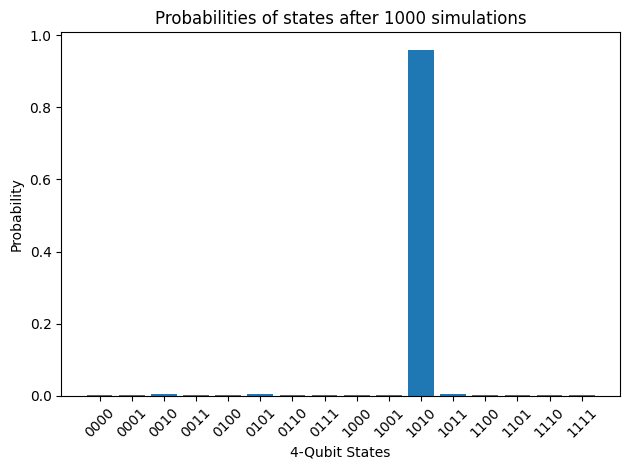

In [18]:
#Plot probability distributions of measured states
fig, ax = plt.subplots()

states = [s for s in results]
counts = [results[s] for s in results]
bar_labels = states


ax.bar(states, counts, label=bar_labels)

ax.set_ylabel('Probability')
ax.set_xlabel('4-Qubit States')
ax.set_title('Probabilities of states after 1000 simulations')
plt.xticks(rotation=45)
plt.tight_layout()  
plt.show()

1010 state comes out with considerably highest amplitude of approximately 0.96 after 3 queries, showing that our Grover's circuit amplified the target state |1010⟩.